# 伝搬損失等高線サーフェスによるセルサイトカバレッジのマッピング

## エグゼクティブサマリー

電気通信のRFプランニングチームは、単一のマクロセル基地局周辺のダウンリンク**伝搬損失サーフェス**を、二次元のカバレッジマップとして描画します。対数距離伝搬モデルと対数正規シャドウフェージングを用いて、本ノートブックは100点の測定グリッド（10km x 10kmのサービスエリアに広がる10 x 10セル、基地局は中心）を構築し、**PROC SGPLOT HEATMAPPARM** とグラデーションカラースケール、基地局の参照線とともに塗りつぶし等高線サーフェスを描画します。

実行したグリッド上で、伝搬損失は基地局周辺の明るい谷部で**50.4 dB**から、最遠のコーナーで**90.0 dB**まで変化し、平均は**75.6 dB**です。損失によって各セルを分類すると、**良好38セル、可61セル、不良1セル**となります。唯一の不良セルは**（9.5, 9.5）km — 基地局の対角線上反対側のコーナー — で89.97 dB**にあり、スモールセル増設の判断前にプランナーが指摘するはずの唯一のカバレッジホールです。

> **プロシジャに関する注記。** SASでは等高線図の伝統的なツールは `PROC GCONTOUR` です。Jennerは GCONTOUR を解析して正しいプロットスペックを出力しますが、そのラスターレンダラーはまだ等高線の幾何を描画しません（画像が空で返ってきます）。この不具合はリグレッションテスト `tests/400922_nb_gcontour_empty_render` として計上されています。この例を実際にレンダリングされた図に完全に基づかせるため、SAS互換の代替手段 — `HEATMAPPARM` ステートメントを伴う `PROC SGPLOT` — を用います。これは同じグリッド化された (x, y, z) サーフェスを、グラデーション凡例付きの塗りつぶし等高線セルとして描画します。

## データソース

**合成データセット：`pathloss_grid`**（100行 — 10 x 10の格子）

| 変数 | 型 | 単位 | 説明 |
|----------|------|-------|-------------|
| `east_km` | 数値 | km | グリッドセル中心の東方距離（0.5～9.5）；x軸 |
| `north_km` | 数値 | km | グリッドセル中心の北方距離（0.5～9.5）；y軸 |
| `path_loss` | 数値 | dB | ダウンリンク伝搬損失 = 58 + 30 log10(距離) + シャドウ；応答変数（z） |
| `zone` | 文字(8) | — | カバレッジ区分：良好（<=75）、可（<=88）、不良（>88） |

基地局はグリッド中心の**（5, 5）km**にあります。伝搬損失は基地局からの距離の常用対数とともに増加します。`3*rand("normal")` のシャドウ項（シード80211）が対数正規フェージングを注入するため、等高線は完全な円形にはなりません。10 x 10の格子は、サーフェス全体が100観測値に収まるようサイズが決められています。

## ステップ1 — 測定グリッドの生成

セル中心の1kmの格子を敷き、**対数距離モデル** `PL = 58 + 30 log10(d)` で伝搬損失を計算します。ここで `d` は（5, 5）kmにある基地局からの距離です。`rand("normal")` のシャドウフェージング項が、実際のドライブテストで見られる変動を再現します。各セルはカバレッジ`区分`に分類されます。`call streaminit` は再現性のためにシードを固定します。

In [1]:
データ pathloss_grid;
   呼出 streaminit(80211);
   長さ zone $12;
   tower_x = 5.0;  tower_y = 5.0;
   繰返 ix = 1 から 10;
      繰返 iy = 1 から 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         もし      path_loss <= 75 なら zone = "良好";
         他 もし path_loss <= 88 なら zone = "可";
         他                         zone = "不良";
         出力;
      終了;
   終了;
   削除 ix iy tower_x tower_y DIST shadow;
   見出 east_km   = "東方距離（km）"
         north_km  = "北方距離（km）"
         path_loss = "伝搬損失（dB）"
         zone      = "カバレッジ区分";
実行;



NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## ステップ2 — サーフェスの要約

プロットの前に、サーフェスを定量化します。`PROC MEANS` は伝搬損失のダイナミックレンジを報告し、`PROC FREQ` は100セルが3つのカバレッジ区分にどう分かれるかを集計します — これがエグゼクティブサマリーで引用されている数値です。

In [2]:
ODS GRAPHICS OFF;

処理 平均 データ=pathloss_grid MIN MAX mean maxdec=1;
   変数 path_loss;
実行;

処理 度数 データ=pathloss_grid ORDER=度数;
   TABLES zone / nocum;
実行;


                                                  The MEANS Procedure

 Variable   Label                    Minimum     Maximum        Mean
 -------------------------------------------------------------------
 path_loss  伝搬損失（dB）                    50.4        90.0        75.6
 -------------------------------------------------------------------

                                                   The FREQ Procedure

カバレッジ区分                  Frequency    Percent
----------------------------------------------
可                               61     61.00
良好                              38     38.00
不良                               1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## ステップ3 — カバレッジホールの特定

伝搬損失の降順でソートすると、最も弱いセルが上位に来ます。これらはプランナーが点検すべき候補の**デッドゾーン**であり、受信信号が最も低く、セッション切断や低スループットのリスクが最も高いセルです。

In [3]:
処理 並替 データ=pathloss_grid out=weakest;
   基準 DESCENDING path_loss;
実行;

処理 印刷 データ=weakest(obs=6) noobs 見出;
   変数 east_km north_km path_loss zone;
実行;



            東方距離（km）              北方距離（km）              伝搬損失（dB）                カバレッジ区分
--------------------  --------------------  --------------------  ---------------------
                 9.5                   9.5         89.9728891641  不良
                 9.5                   0.5         85.9296978639  可
                 6.5                   0.5         84.5845683025  可
                 0.5                   0.5         84.5118930355  可
                 8.5                   0.5         84.1534148341  可
                 9.5                   8.5         83.7015943773  可

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## ステップ4 — 伝搬損失等高線サーフェスの描画

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` は、伝搬損失で色付けされたグリッド点ごとの塗りつぶしセルを描画します — カバレッジフットプリントの塗りつぶし等高線図です。`COLORMODEL=` リストは、青から赤への発散型グラデーション（青＝低損失＝強い信号、赤＝高損失＝弱い信号）を定義し、`GRADLEGEND` はdBのカラースケールを付加します。破線の `REFLINE` は東方5、北方5にある基地局を示します。

                                                  ダウンリンク伝搬損失サーフェス（dB）                                                   
                                          10km x 10kmグリッド上の単一マクロセル基地局（5, 5 km）                                          




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to ダウンリンク伝搬損失サーフェス（dB）.
NOTE: Option TITLE2 changed to 10km x 10kmグリッド上の単一マクロセル基地局（5, 5 km）.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


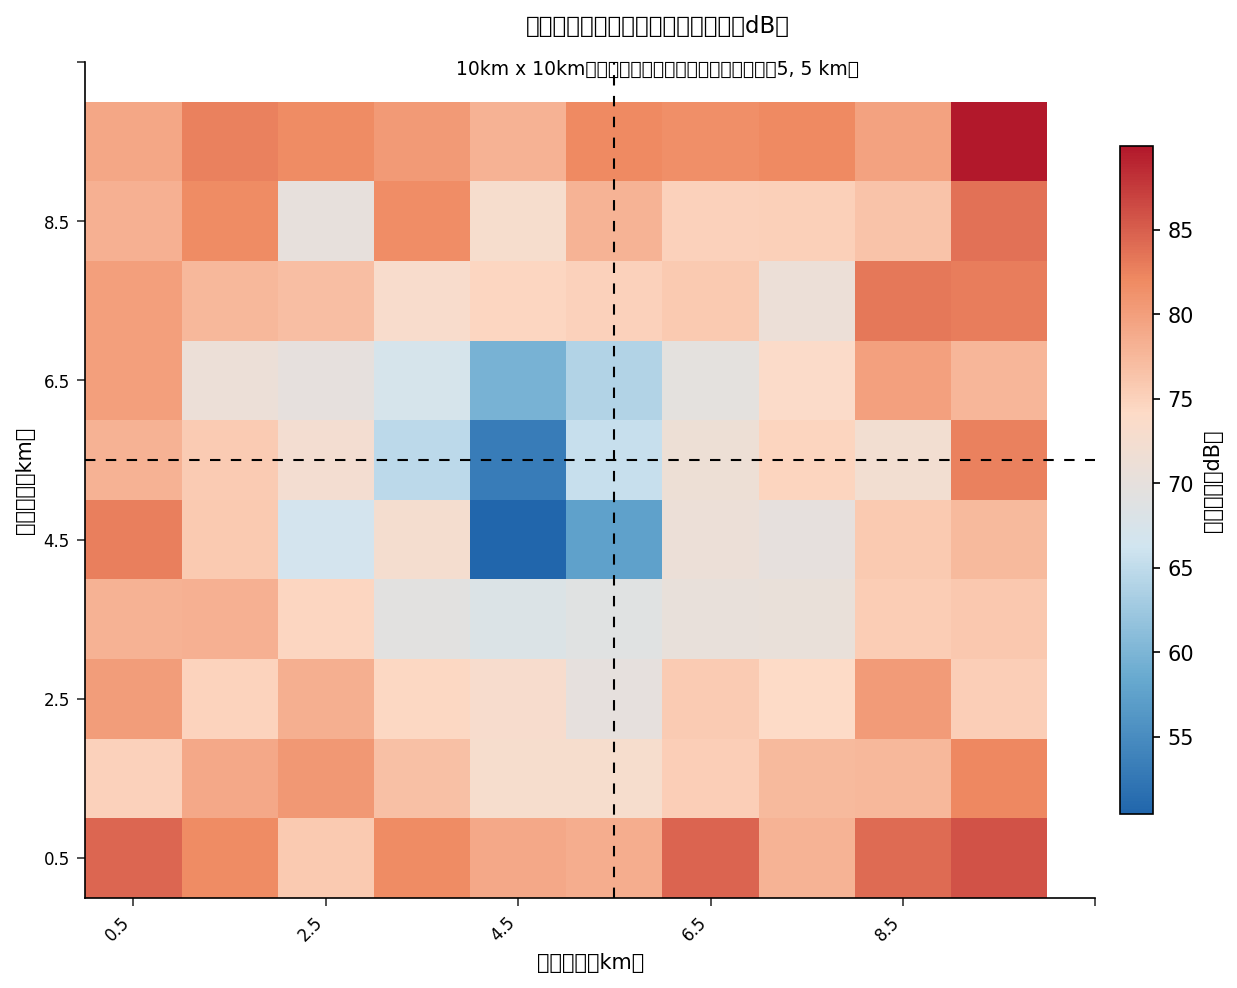

In [4]:
ODS GRAPHICS ON;
表題 "ダウンリンク伝搬損失サーフェス（dB）";
title2 "10km x 10kmグリッド上の単一マクロセル基地局（5, 5 km）";

処理 SGPLOT データ=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / 表題="伝搬損失（dB）";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) 見出="東方距離（km）";
   YAXIS VALUES=(0 2 4 6 8 10) 見出="北方距離（km）";
実行;

表題; title2;


## ステップ5 — カバレッジ区分の内訳

ブリーフィング資料では、フットプリントのうち良好・可・不良がそれぞれ何割かという要約も求められます。`区分`分類の `VBAR` により、それが一目でわかり、上の等高線サーフェスと対をなします。

                                                       カバレッジ区分の内訳                                                       




NOTE: Option TITLE changed to カバレッジ区分の内訳.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


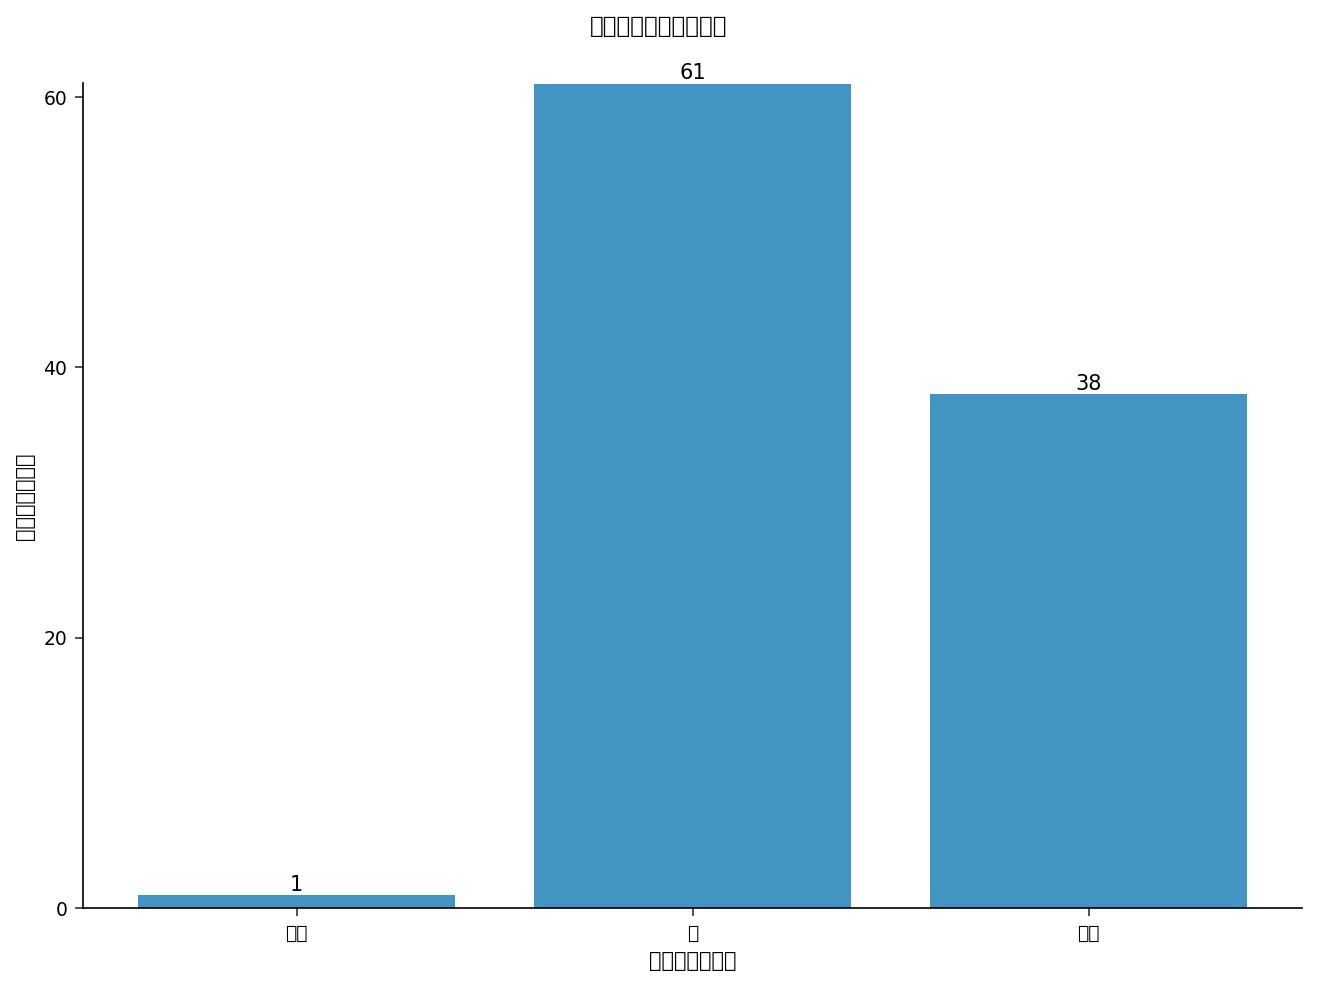

In [5]:
表題 "カバレッジ区分の内訳";

処理 SGPLOT データ=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS 見出="カバレッジ区分";
   YAXIS 見出="グリッドセル数" VALUES=(0 20 40 60);
実行;

表題;


## 結果の解釈

等高線サーフェスは、想定どおりの伝搬物理を裏づけています。伝搬損失は**（5, 5）kmの基地局周辺の狭い青い谷部**で最も低く — ここが受信信号が最良の良好区域です — コーナーに向かって距離の対数とともに上昇します。対数正規シャドウフェージングを注入したため、帯は同心円にはならず、境界に沿ったギザギザの赤いセルがシャドウフェージングの影響を受けた縁です。

実際に対応すべき読み取りは、**（9.5, 9.5）kmにある唯一の不良セル（89.97 dB）**であり、基地局の対角線上反対側のコーナーで、88 dBの設計しきい値を超える唯一の地点です。**100セル中61セルが可、わずか1セルが不良**であることから、このマクロセルはサービスエリアを良好にカバーしています。この唯一のホールは、既知の需要ホットスポットと重なる場合に限り、**スモールセル増設または北東コーナーへのセクター再チルト**を正当化するでしょう。等高線サーフェスはブリーフィングにそのまま使える要約であり、カバレッジ区分の棒グラフはキャパシティプランナーが上位に報告する一数値の内訳を示します。